# Resonator TOF bring-up

First real-resonator measurement notebook.

Plan:

1. AWG emits a 50 MHz IF readout pulse.
2. SGS100A is the microwave LO.
3. The resonator drive is treated as upper-sideband:
   `f_resonator_drive = f_sgs + fc`.
4. Start at the design frequency, 5.9 GHz, so `f_sgs = 5.85 GHz`.
5. Run TOF first, then use SGS100A to sweep around the resonator.

Run cells in order. Keep the initial `READOUT_GAIN` conservative and increase
only after checking the ATS voltage range.

In [68]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from QAWG import AWGAlazar, ExperimentProgram, LinearSweep, ValuesSweep, MHz, ns, us
from QAWG import calculate_window
from QAWG.instrument import RohdeSchwarzSGS100A

## Hardware and frequency parameters

In [69]:
AWG_RESOURCE = "TCPIP0::192.168.10.171::inst0::INSTR"
SGS100A_ADDRESS = "192.168.10.90"

AWG_SAMPLE_RATE_HZ = 2.5e9
ALAZAR_SAMPLE_RATE_HZ = 1e9

RESONATOR_DESIGN_HZ = 5.9e9
FC_HZ = 50 * MHz
SIDEBAND = +1  # +1: RF = SGS + fc, -1: RF = SGS - fc
SGS_CENTER_HZ = RESONATOR_DESIGN_HZ - SIDEBAND * FC_HZ

SGS_POWER_DBM = 0.0
SGS_SETTLE_S = 0.05

# Physical wiring. Adjust these before running if the bench wiring differs.
AWG_CH = 1
MARKER_CH = 1
ADC_CHANNEL = "CHB"

CHANNEL_AMPLITUDE_VPP = 0.5
READOUT_GAIN_FRACTION = 1
READOUT_GAIN = READOUT_GAIN_FRACTION * CHANNEL_AMPLITUDE_VPP / 2
READOUT_LENGTH = 600 * ns
EDGE_SIGMA = 10 * ns
MARKER_PADDING = 500 * ns
TRIGGER_DELAY = 500 * ns
INTEGRATE_TIME = 1.0 * us
ACQUIRE_LENGTH = 1.5 * us
FINAL_DELAY = 100.0 * us

TOF_N_AVERAGE = 1000
TRIGGER_LEVEL = 140
ALAZAR_TIMEOUT_MS = 60_000



print(f"fc = {FC_HZ / MHz:.3f} MHz")
print(f"Design resonator = {RESONATOR_DESIGN_HZ / 1e9:.9f} GHz")
print(f"Initial SGS100A = {SGS_CENTER_HZ / 1e9:.9f} GHz")
print(f"AWG channel amplitude = {CHANNEL_AMPLITUDE_VPP:.3f} Vpp")
print(f"Readout gain fraction = {READOUT_GAIN_FRACTION:.6f}")
print(f"Readout envelope peak = {READOUT_GAIN * 1e3:.6f} mV")
print(
    "Initial microwave drive = "
    f"{(SGS_CENTER_HZ + SIDEBAND * FC_HZ) / 1e9:.9f} GHz"
)

fc = 50.000 MHz
Design resonator = 5.900000000 GHz
Initial SGS100A = 5.850000000 GHz
AWG channel amplitude = 0.500 Vpp
Readout gain fraction = 1.000000
Readout envelope peak = 250.000000 mV
Initial microwave drive = 5.900000000 GHz


## Connect AWG + ATS

In [70]:
experiment = AWGAlazar.connect(
    AWG_RESOURCE,
    awg_sample_rate_hz=AWG_SAMPLE_RATE_HZ,
    alazar_sample_rate_hz=ALAZAR_SAMPLE_RATE_HZ,
    acquire_window_s=ACQUIRE_LENGTH,
    tone_frequency_hz=FC_HZ,
    trigger_delay_s=TRIGGER_DELAY,
    integrate_time_s=INTEGRATE_TIME,
    adc_channel=ADC_CHANNEL,
    trigger_slope="rising",
    trigger_level=TRIGGER_LEVEL,
    timeout_ms=ALAZAR_TIMEOUT_MS,
    use_external_10mhz_reference=True,
)

print("AWG:", experiment.awg.identify())
print("ATS input channel:", experiment.adc_channel_name)
print("ATS acquire window:", experiment.acquire_window_cycles, "samples")
print("ATS initial post-trigger delay:", experiment.trigger_delay_s / ns, "ns")
print("ATS integration time:", experiment.integrate_time_s / ns, "ns")

AWG: TEKTRONIX,AWG5208,B030598,FV:6.6.0131.0
ATS input channel: CHB
ATS acquire window: 1536 samples
ATS initial post-trigger delay: 500.00000000000006 ns
ATS integration time: 999.9999999999999 ns


## Connect and configure SGS100A

In [71]:
sgs = RohdeSchwarzSGS100A(SGS100A_ADDRESS)
sgs.frequency = SGS_CENTER_HZ
sgs.power = SGS_POWER_DBM
sgs.IQ_state = "on"
sgs.pulsemod_state = "off"
sgs.configure_lo_output(True, mode="LO")
sgs.on()

print("SGS100A:", sgs.idn())
print(f"Frequency: {sgs.frequency / 1e9:.9f} GHz")
print(f"Power: {sgs.power:.3f} dBm")
print("Main RF output:", sgs.status)
print("External IQ modulation:", sgs.IQ_state)
print("Pulse modulation:", sgs.pulsemod_state)
print("Rear REF/LO output:", sgs.ref_lo_output)
print("Instrument error:", sgs.check_error())

Connected to: Rohde&Schwarz,SGS100A,1416.0505k02/112369,4.2.76.0-4.30.046.295
SGS100A: Rohde&Schwarz,SGS100A,1416.0505k02/112369,4.2.76.0-4.30.046.295
Frequency: 5.850000000 GHz
Power: 0.000 dBm
Main RF output: on
External IQ modulation: on
Pulse modulation: off
Rear REF/LO output: LO
Instrument Status: 0,"No error"
Instrument error: 0,"No error"


## TOF program

In [72]:
class ResonatorTOFProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.declare_gen(
            "readout",
            ch=cfg["awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["acquire_length"],
            demod_freq=cfg["frequency"],
            waveform_ch=cfg["awg_ch"],
            marker_channel=cfg["marker_ch"],
            marker_padding=cfg["marker_padding"],
            integrate_time=cfg["integrate_time"],
        )
        self.add_pulse(
            "tof_readout",
            gen="readout",
            style="gaussian_square",
            length=cfg["readout_length"],
            edge_sigma=cfg["edge_sigma"],
            frequency=cfg["frequency"],
            gain=cfg["readout_gain"],
            readout=True,
        )

    def _body(self, cfg):
        self.play("tof_readout", at=0)
        self.trigger("ro", trigger_delay=cfg["trigger_delay"])


tof_cfg = {
    "awg_ch": AWG_CH,
    "marker_ch": MARKER_CH,
    "adc_channel": ADC_CHANNEL,
    "channel_amplitude_vpp": CHANNEL_AMPLITUDE_VPP,
    "frequency": FC_HZ,
    "readout_length": READOUT_LENGTH,
    "marker_padding": MARKER_PADDING,
    "edge_sigma": EDGE_SIGMA,
    "readout_gain": READOUT_GAIN,
    "acquire_length": ACQUIRE_LENGTH,
    "trigger_delay": 0,
    "integrate_time": INTEGRATE_TIME,
}

## Compile TOF

In [73]:
tof_program = ResonatorTOFProgram(tof_cfg, final_delay_s=FINAL_DELAY)
tof_program.REMOVE_DC_OFFSET = True
tof_compiled = tof_program.compile(hardware=experiment)

if AWG_CH == MARKER_CH:
    print(f"Analog readout and marker share AWG CH{AWG_CH}.")

marker_samples = np.flatnonzero(tof_compiled.marker_waveforms[0])
marker_start_ns = marker_samples[0] / experiment.awg_sample_rate_hz / ns
marker_stop_ns = (marker_samples[-1] + 1) / experiment.awg_sample_rate_hz / ns
readout_start_ns, readout_stop_ns = tof_compiled.readout_windows_s[0] / ns

print("Sequence steps:", tof_compiled.number_of_sequence_steps)
print("AWG step duration:", tof_compiled.step_duration_s / us, "us")
print(f"Readout IF: {FC_HZ / MHz:.3f} MHz")
print(f"Readout window: {readout_start_ns:.3f} to {readout_stop_ns:.3f} ns")
print(f"Marker window: {marker_start_ns:.3f} to {marker_stop_ns:.3f} ns")
print("ATS post-trigger delay:", TRIGGER_DELAY / ns, "ns")
print("ATS acquire window:", experiment.acquire_window_cycles, "samples")

Analog readout and marker share AWG CH1.
Sequence steps: 1
AWG step duration: 102.0 us
Readout IF: 50.000 MHz
Readout window: 500.000 to 1100.000 ns
Marker window: 0.000 to 1600.000 ns
ATS post-trigger delay: 500.00000000000006 ns
ATS acquire window: 1536 samples


## Acquire TOF trace

In [74]:
tof_result = tof_compiled.acquire(
    n_average=TOF_N_AVERAGE,
    filter_type="boxcar",
)

raw_time_ns = tof_result.raw_time_s / ns
iq_time_ns = tof_result.iq_time_s / ns
raw_avg_mv = tof_result.trace_average("ro")[0] * 1e3
iq_avg = tof_result.iq_trace_average("ro")[0]
iq_abs_mv = np.abs(iq_avg) * 1e3
iq_point = tof_result.iq_average("ro")[0]

print("Raw records (shot, step, time):", tof_result.raw.shape)
print("IQ traces (shot, step, time):", tof_result.iq_traces.shape)
print(f"Integrated IQ: I={iq_point.real * 1e3:.6f} mV, Q={iq_point.imag * 1e3:.6f} mV")
print("SGS error:", sgs.check_error())
print("AWG error:", experiment.awg.error())
for key, value in experiment.capture_diagnostics().items():
    print(f"{key}: {value}")

Raw records (shot, step, time): (1000, 1, 1536)
IQ traces (shot, step, time): (1000, 1, 1517)
Integrated IQ: I=-0.009735 mV, Q=0.308897 mV
Instrument Status: 0,"No error"
SGS error: 0,"No error"
AWG error: 0,"No error"
adc_channel: CHB
adc_bits: 12
adc_lsb_mv: 0.1953125
raw_code_min: 32528
raw_code_max: 32944
mean_offset_mv: -0.27765566507975276
average_peak_to_peak_mv: 1.7628906249999996
shot_noise_std_mv: 0.42381734722983505


## Plot raw and demodulated TOF

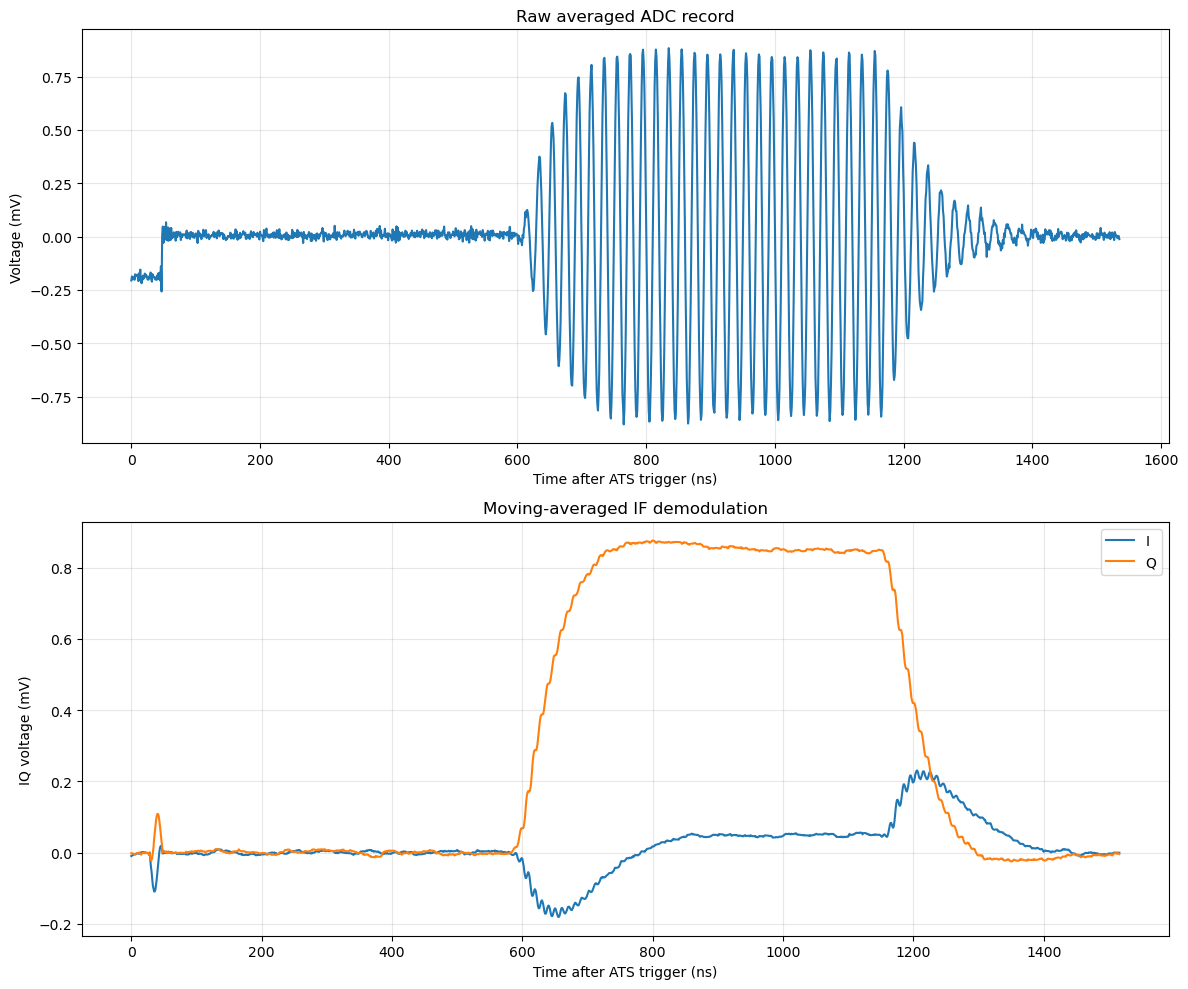

In [75]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)
axes[0].plot(raw_time_ns, raw_avg_mv)
axes[0].set_title("Raw averaged ADC record")
axes[0].set_xlabel("Time after ATS trigger (ns)")
axes[0].set_ylabel("Voltage (mV)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(iq_time_ns, iq_avg.real * 1e3, label="I")
axes[1].plot(iq_time_ns, iq_avg.imag * 1e3, label="Q")
axes[1].set_title("Moving-averaged IF demodulation")
axes[1].set_xlabel("Time after ATS trigger (ns)")
axes[1].set_ylabel("IQ voltage (mV)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()


## Calculate suggested trigger and integration window

Initial post-trigger delay: 0.000 ns
Measured readout arrival: 633.566 ns
Compiled readout duration: 600.000 ns
Suggested post-trigger delay: 583.566 ns
Suggested integration window: 0.000 to 670.000 ns
DC offset removal: True
Use these after checking the plotted window:
TRIGGER_DELAY = 583.566 ns
INTEGRATE_TIME = 670.000 ns


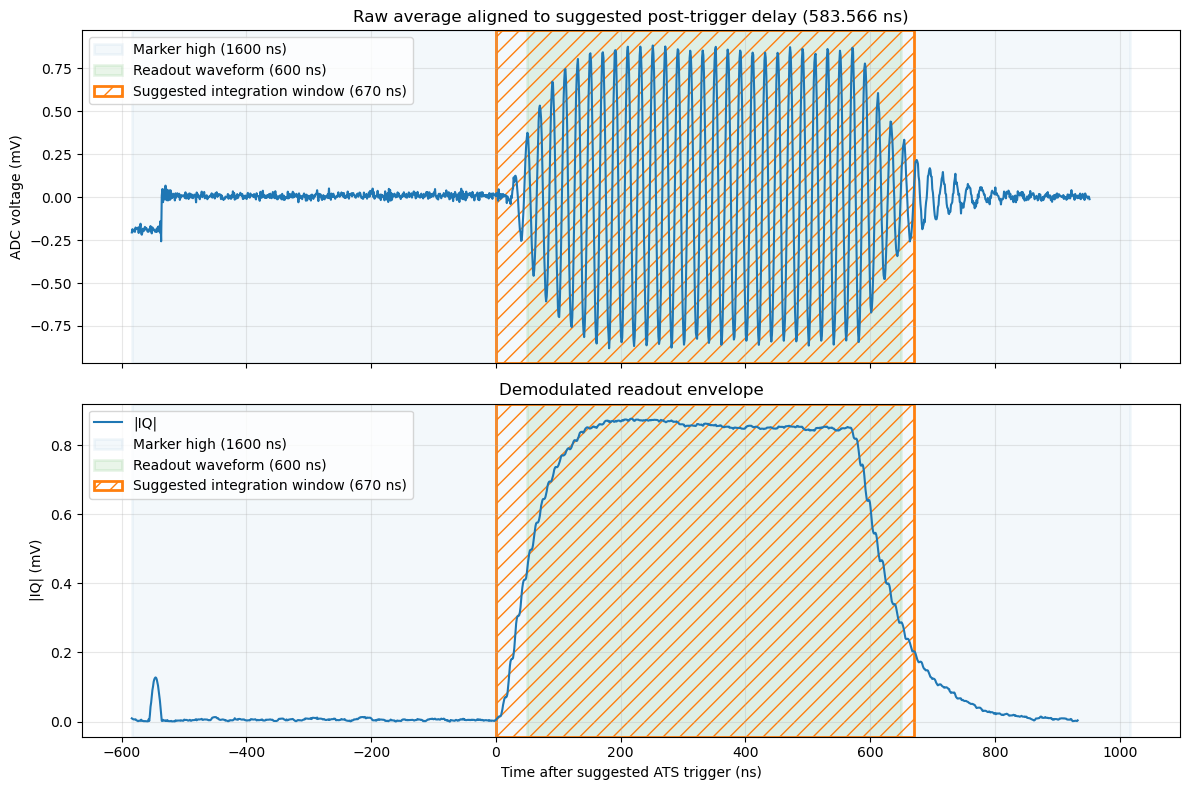

In [76]:
WINDOW_TRIGGER_LEAD = 50 * ns
WINDOW_INTEGRATION_GUARD = 20 * ns

window = calculate_window(
    tof_result,
    trigger_lead_s=WINDOW_TRIGGER_LEAD,
    integration_guard_s=WINDOW_INTEGRATION_GUARD,
    plot=True,
    report=True,
)

SUGGESTED_TRIGGER_DELAY = window.suggested_trigger_delay_s
SUGGESTED_INTEGRATE_TIME = window.integration_stop_s - window.integration_start_s

print("Use these after checking the plotted window:")
print(f"TRIGGER_DELAY = {SUGGESTED_TRIGGER_DELAY / ns:.3f} ns")
print(f"INTEGRATE_TIME = {SUGGESTED_INTEGRATE_TIME / ns:.3f} ns")

In [77]:
READOUT_LENGTH = 1000* ns
TRIGGER_DELAY = SUGGESTED_TRIGGER_DELAY

## Optional: SGS100A frequency sweep around 5.9 GHz

In [ ]:
# Sweep target microwave drive frequencies. SGS100A is adjusted by subtracting fc.
DRIVE_SPAN_HZ = 20 * MHz
DRIVE_POINTS = 41
SWEEP_N_AVERAGE = 300

drive_frequency_hz = np.linspace(
    RESONATOR_DESIGN_HZ - DRIVE_SPAN_HZ / 2,
    RESONATOR_DESIGN_HZ + DRIVE_SPAN_HZ / 2,
    DRIVE_POINTS,
)
sgs_frequency_hz = drive_frequency_hz - SIDEBAND * FC_HZ

sweep_iq = []
sweep_peak_mv = []
sweep_arrival_ns = []

for index, (drive_hz, sgs_hz) in enumerate(zip(drive_frequency_hz, sgs_frequency_hz)):
    sgs.frequency = float(sgs_hz)
    time.sleep(SGS_SETTLE_S)
    result = tof_compiled.acquire(
        n_average=SWEEP_N_AVERAGE,
        filter_type="boxcar",
    )
    avg_iq = result.iq_trace_average("ro")[0]
    mag_mv = np.abs(avg_iq) * 1e3
    point = result.iq_average("ro")[0]

    sweep_iq.append(point)

    print(
        f"{index + 1:02d}/{DRIVE_POINTS}: "
        f"drive={drive_hz / 1e9:.9f} GHz, "
        f"sgs={sgs_hz / 1e9:.9f} GHz, "
        f"|IQ|={abs(point) * 1e3:.6f} mV, "
    )

sweep_iq = np.asarray(sweep_iq)
sweep_peak_mv = np.asarray(sweep_peak_mv)
sweep_arrival_ns = np.asarray(sweep_arrival_ns)

01/41: drive=5.890000000 GHz, sgs=5.840000000 GHz, |IQ|=0.132520 mV, 
02/41: drive=5.890500000 GHz, sgs=5.840500000 GHz, |IQ|=0.140884 mV, 
03/41: drive=5.891000000 GHz, sgs=5.841000000 GHz, |IQ|=0.144543 mV, 
04/41: drive=5.891500000 GHz, sgs=5.841500000 GHz, |IQ|=0.151850 mV, 
05/41: drive=5.892000000 GHz, sgs=5.842000000 GHz, |IQ|=0.162310 mV, 
06/41: drive=5.892500000 GHz, sgs=5.842500000 GHz, |IQ|=0.172801 mV, 
07/41: drive=5.893000000 GHz, sgs=5.843000000 GHz, |IQ|=0.184219 mV, 
08/41: drive=5.893500000 GHz, sgs=5.843500000 GHz, |IQ|=0.195293 mV, 
09/41: drive=5.894000000 GHz, sgs=5.844000000 GHz, |IQ|=0.210576 mV, 
10/41: drive=5.894500000 GHz, sgs=5.844500000 GHz, |IQ|=0.227146 mV, 
11/41: drive=5.895000000 GHz, sgs=5.845000000 GHz, |IQ|=0.243514 mV, 
12/41: drive=5.895500000 GHz, sgs=5.845500000 GHz, |IQ|=0.261615 mV, 
13/41: drive=5.896000000 GHz, sgs=5.846000000 GHz, |IQ|=0.286573 mV, 
14/41: drive=5.896500000 GHz, sgs=5.846500000 GHz, |IQ|=0.303924 mV, 
15/41: drive=5.89700

## Plot frequency sweep

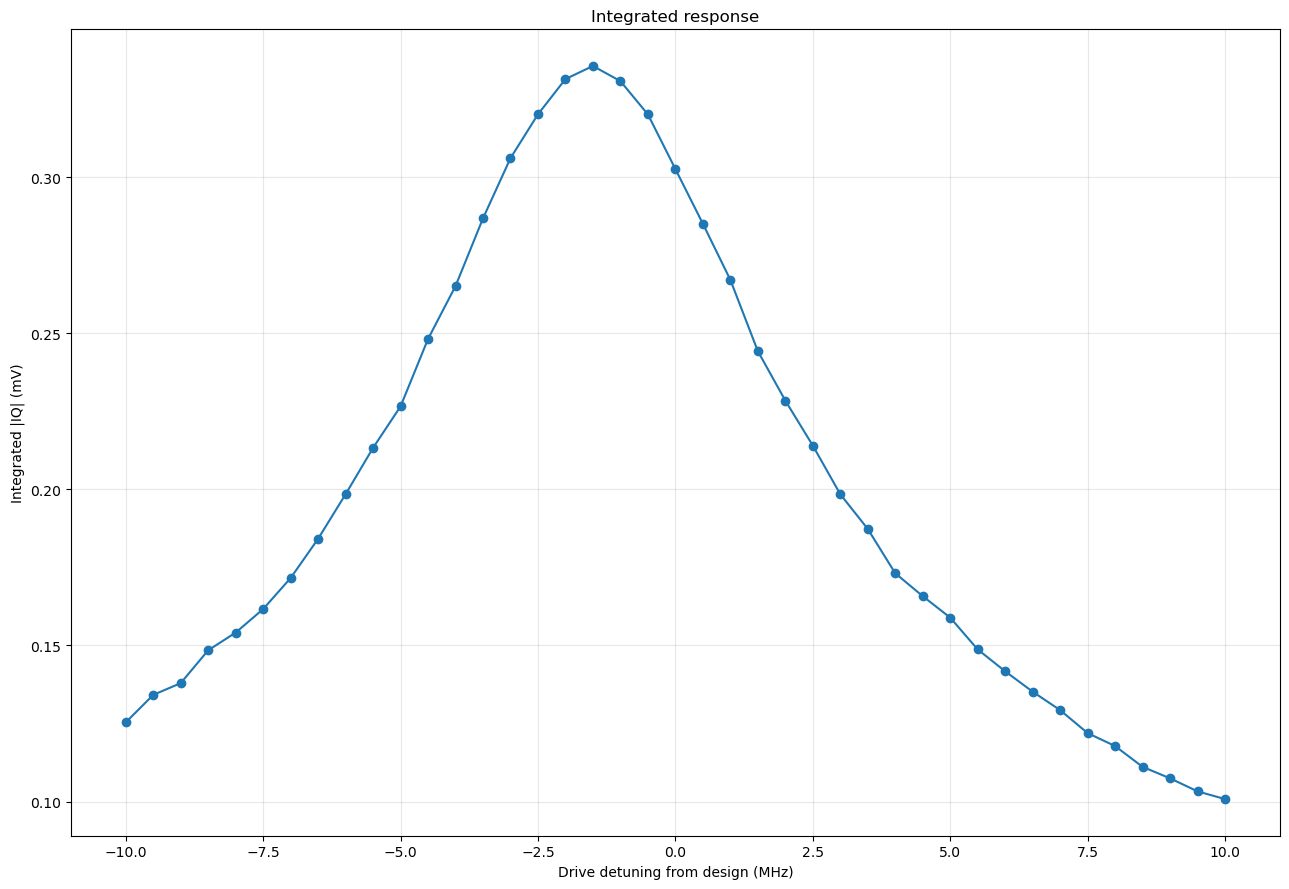

In [15]:
drive_detuning_mhz = (drive_frequency_hz - RESONATOR_DESIGN_HZ) / MHz

fig, axes = plt.subplots( figsize=(13, 9))
axes.plot(drive_detuning_mhz, np.abs(sweep_iq) * 1e3, "o-")
axes.set_xlabel("Drive detuning from design (MHz)")
axes.set_ylabel("Integrated |IQ| (mV)")
axes.set_title("Integrated response")
axes.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Optional: fixed SGS100A, AWG fc sweep from 50 to 150 MHz

In [11]:
# Keep SGS100A fixed at 5.9 GHz - 50 MHz = 5.85 GHz.
# The microwave drive follows RF = SGS + fc, so this sweeps 5.90 to 6.00 GHz.
# This uses one AWG sequence list upload instead of compiling/uploading in a loop.

class AWGFrequencySweepTOFProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.declare_gen(
            "readout",
            ch=cfg["awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        fc = self.add_sweep(
            "fc",
            LinearSweep(
                cfg["fc_start"],
                cfg["fc_stop"],
                cfg["fc_points"],
            ),
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["acquire_length"],
            # Placeholder metadata. Each step is manually demodulated below.
            demod_freq=cfg["fc_start"],
            waveform_ch=cfg["awg_ch"],
            marker_channel=cfg["marker_ch"],
            marker_padding=cfg["marker_padding"],
            integrate_time=cfg["integrate_time"],
        )
        self.add_pulse(
            "tof_readout",
            gen="readout",
            style="gaussian_square",
            length=cfg["readout_length"],
            edge_sigma=cfg["edge_sigma"],
            frequency=fc,
            gain=cfg["readout_gain"],
            readout=True,
        )

    def _body(self, cfg):
        self.play("tof_readout", at=0)
        self.trigger("ro", trigger_delay=cfg["trigger_delay"])


FIXED_SGS_HZ = RESONATOR_DESIGN_HZ - 100 * MHz
AWG_FC_START_HZ = 50 * MHz
AWG_FC_STOP_HZ = 150 * MHz
AWG_FC_POINTS = 51
AWG_FC_SWEEP_N_AVERAGE = 300

awg_fc_cfg = {
    **tof_cfg,
    "fc_start": AWG_FC_START_HZ,
    "fc_stop": AWG_FC_STOP_HZ,
    "fc_points": AWG_FC_POINTS,
    # Keep sequence metadata matched to the currently configured ATS timing.
    # This avoids reconfiguring the ATS clock, which can hit ApiPllNotLocked.
    "trigger_delay": experiment.trigger_delay_s,
    "integrate_time": experiment.integrate_time_s,
}

sgs.frequency = FIXED_SGS_HZ
time.sleep(SGS_SETTLE_S)
print(f"Fixed SGS100A frequency: {sgs.frequency / 1e9:.9f} GHz")
print(f"Using current ATS trigger delay: {experiment.trigger_delay_s / ns:.3f} ns")
print(f"Using current integration time: {experiment.integrate_time_s / ns:.3f} ns")

program = AWGFrequencySweepTOFProgram(
    awg_fc_cfg,
    name="awg_fc_sequence_sweep",
    final_delay_s=FINAL_DELAY,
)
program.REMOVE_DC_OFFSET = True
compiled = program.compile(hardware=experiment)

# Upload the full 51-step sequence once. Do not use compiled.acquire() here,
# because it reconfigures the ATS clock before capture.
compiled.upload(hardware=experiment)
raw_time_s, _, _, _ = experiment.acquire_sequence_traces(
    number_of_steps=compiled.number_of_sequence_steps,
    number_of_averages=AWG_FC_SWEEP_N_AVERAGE,
    filter_type="boxcar",
    remove_dc_offset=compiled.remove_dc_offset,
)

awg_fc_hz = compiled.axis("fc")
awg_drive_hz = FIXED_SGS_HZ + SIDEBAND * awg_fc_hz
raw = experiment.last_sequence_records_volts
if raw is None:
    raise RuntimeError("No sequence records returned")

i0, i1 = experiment.integrate_window_cycles
i1 = min(i1, raw.shape[2])
if i0 >= i1:
    raise ValueError("Integration window is empty")

manual_iq_shots = np.empty(
    (raw.shape[0], raw.shape[1]),
    dtype=np.complex128,
)
awg_fc_iq_traces = np.empty(
    (raw.shape[1], raw.shape[2]),
    dtype=np.complex128,
)
awg_fc_iq = []
awg_fc_peak_mv = []
awg_fc_arrival_ns = []
awg_fc_windows = []

for index, (fc_hz, drive_hz) in enumerate(zip(awg_fc_hz, awg_drive_hz)):
    reference = np.exp(-1j * 2 * np.pi * fc_hz * raw_time_s)
    downconverted = 2.0 * raw[:, index, :] * reference[None, :]
    manual_iq_shots[:, index] = np.mean(downconverted[:, i0:i1], axis=1)
    average_trace = np.mean(downconverted, axis=0)
    awg_fc_iq_traces[index] = average_trace

    point = np.mean(manual_iq_shots[:, index])
    mag_mv = np.abs(average_trace) * 1e3

    awg_fc_iq.append(point)
    awg_fc_windows.append(
        (
            experiment.trigger_delay_s,
            compiled.readout_windows_s[index, 0],
            compiled.readout_windows_s[index, 1],
        )
    )
    print(
        f"{index + 1:02d}/{AWG_FC_POINTS}: "
        f"fc={fc_hz / MHz:8.3f} MHz, "
        f"drive={drive_hz / 1e9:.9f} GHz, "
        f"|IQ|={abs(point) * 1e3:.6f} mV"
    )

awg_fc_iq = np.asarray(awg_fc_iq)
awg_fc_peak_mv = np.asarray(awg_fc_peak_mv)
awg_fc_arrival_ns = np.asarray(awg_fc_arrival_ns)
awg_fc_windows = np.asarray(awg_fc_windows)


Fixed SGS100A frequency: 5.800000000 GHz
Using current ATS trigger delay: 0.000 ns
Using current integration time: 1000.000 ns
01/51: fc=  50.000 MHz, drive=5.850000000 GHz, |IQ|=0.001789 mV
02/51: fc=  52.000 MHz, drive=5.852000000 GHz, |IQ|=0.011716 mV
03/51: fc=  54.000 MHz, drive=5.854000000 GHz, |IQ|=0.009966 mV
04/51: fc=  56.000 MHz, drive=5.856000000 GHz, |IQ|=0.009282 mV
05/51: fc=  58.000 MHz, drive=5.858000000 GHz, |IQ|=0.008400 mV
06/51: fc=  60.000 MHz, drive=5.860000000 GHz, |IQ|=0.010056 mV
07/51: fc=  62.000 MHz, drive=5.862000000 GHz, |IQ|=0.010696 mV
08/51: fc=  64.000 MHz, drive=5.864000000 GHz, |IQ|=0.011144 mV
09/51: fc=  66.000 MHz, drive=5.866000000 GHz, |IQ|=0.012265 mV
10/51: fc=  68.000 MHz, drive=5.868000000 GHz, |IQ|=0.012026 mV
11/51: fc=  70.000 MHz, drive=5.870000000 GHz, |IQ|=0.014343 mV
12/51: fc=  72.000 MHz, drive=5.872000000 GHz, |IQ|=0.014814 mV
13/51: fc=  74.000 MHz, drive=5.874000000 GHz, |IQ|=0.014555 mV
14/51: fc=  76.000 MHz, drive=5.876000000

## Plot fixed-SGS AWG-fc sweep

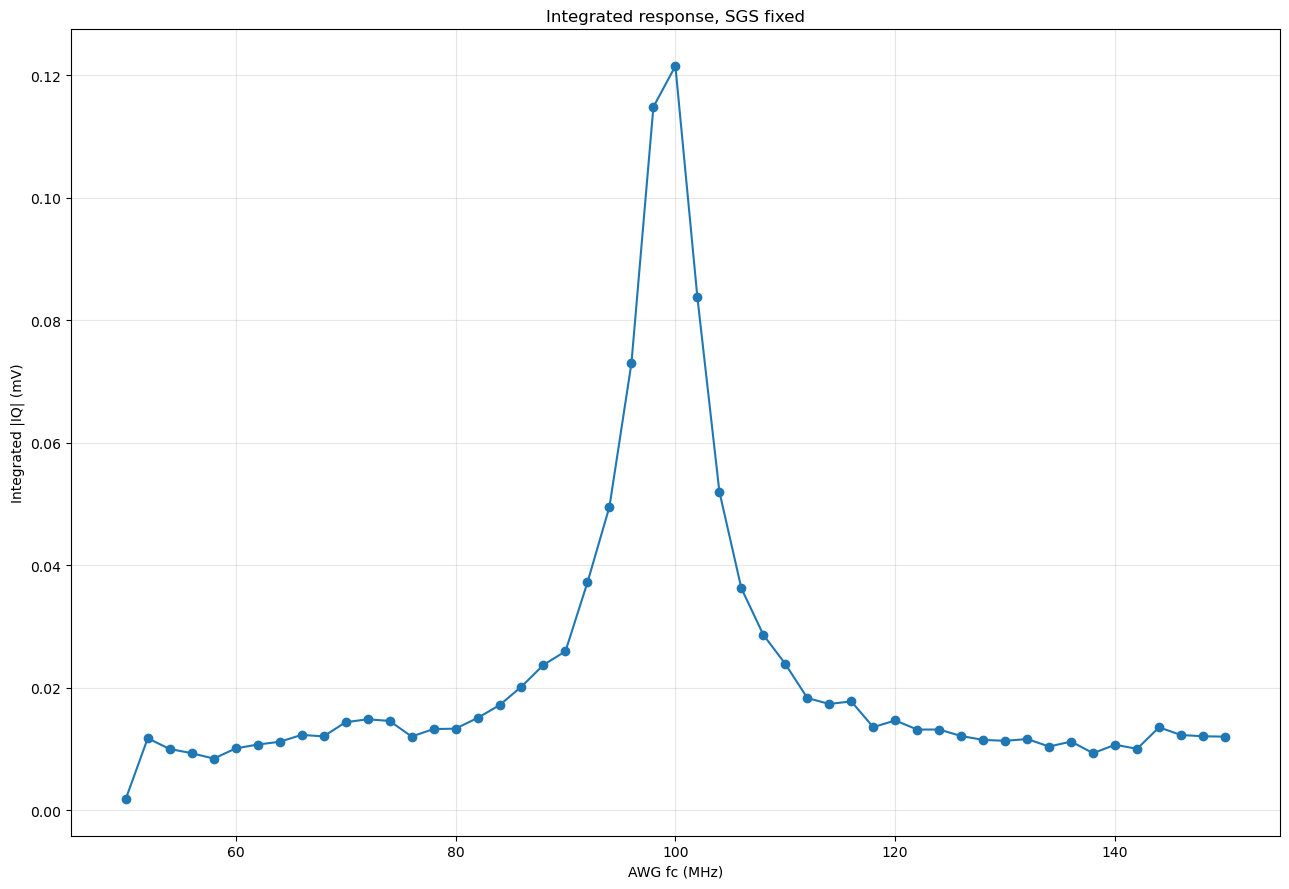

In [12]:
awg_fc_mhz = awg_fc_hz / MHz
awg_drive_ghz = awg_drive_hz / 1e9

fig, axes = plt.subplots( figsize=(13, 9))
axes.plot(awg_fc_mhz, np.abs(awg_fc_iq) * 1e3, "o-")
axes.set_xlabel("AWG fc (MHz)")
axes.set_ylabel("Integrated |IQ| (mV)")
axes.set_title("Integrated response, SGS fixed")
axes.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Save data

In [ ]:
output = Path("resonator_tof_capture.npz")
np.savez(
    output,
    resonator_design_hz=RESONATOR_DESIGN_HZ,
    fc_hz=FC_HZ,
    sideband=SIDEBAND,
    sgs_center_hz=SGS_CENTER_HZ,
    raw_time_ns=raw_time_ns,
    raw_avg_mv=raw_avg_mv,
    iq_time_ns=iq_time_ns,
    iq_avg=iq_avg,
    arrival_ns=arrival_ns,
    drive_frequency_hz=globals().get("drive_frequency_hz", np.array([])),
    sgs_frequency_hz=globals().get("sgs_frequency_hz", np.array([])),
    sweep_iq=globals().get("sweep_iq", np.array([])),
    sweep_peak_mv=globals().get("sweep_peak_mv", np.array([])),
    sweep_arrival_ns=globals().get("sweep_arrival_ns", np.array([])),
    fixed_sgs_hz=globals().get("FIXED_SGS_HZ", np.nan),
    awg_fc_hz=globals().get("awg_fc_hz", np.array([])),
    awg_drive_hz=globals().get("awg_drive_hz", np.array([])),
    awg_fc_iq=globals().get("awg_fc_iq", np.array([])),
    awg_fc_peak_mv=globals().get("awg_fc_peak_mv", np.array([])),
    awg_fc_arrival_ns=globals().get("awg_fc_arrival_ns", np.array([])),
    awg_fc_windows=globals().get("awg_fc_windows", np.array([])),
)
print(output.resolve())

# test tomography

This section is written like the AWG `fc` sequence-list sweep above. The goal is
to teach the full data path:

1. Build a two-step AWG sequence: reference drive off, signal drive on.
2. Upload the sequence once.
3. Acquire many single shots without calling `compiled.acquire()`.
4. Manually demodulate the raw records.
5. Project each shot onto one temporal mode.
6. Normalize with the reference shots.
7. Reconstruct a density matrix and plot a Wigner function.

This is resonator output-mode heterodyne tomography. It is a pipeline sanity
check until the gain/noise calibration is tied to photon units.

In [78]:
from QAWG.tomography import (
    coherent_density_matrix,
    heterodyne_ml_density_matrix,
    normalize_heterodyne_reference,
    project_temporal_mode,
    temporal_mode_weights,
    wigner_function,
)


## Step 1: define a two-step tomography sequence

In [101]:
class ResonatorTomographySequenceProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.declare_gen(
            "readout",
            ch=cfg["awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )

        readout_gain = self.add_sweep(
            "readout_gain",
            ValuesSweep(
                (
                    cfg["reference_gain"],
                    cfg["signal_gain"],
                )
            ),
        )

        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["acquire_length"],
            demod_freq=cfg["frequency"],
            waveform_ch=cfg["awg_ch"],
            marker_channel=cfg["marker_ch"],
            marker_padding=cfg["marker_padding"],
            integrate_time=cfg["integrate_time"],
        )

        self.add_pulse(
            "tomography_readout",
            gen="readout",
            style="gaussian_square",
            length=cfg["readout_length"],
            edge_sigma=cfg["edge_sigma"],
            frequency=cfg["frequency"],
            gain=readout_gain,
            readout=True,
        )

    def _body(self, cfg):
        self.play("tomography_readout", at=0)
        self.trigger("ro", trigger_delay=cfg["trigger_delay"])


## Step 2: choose tomography parameters

In [142]:
TOMO_N_SHOTS = 2000
TOMO_FILTER_TYPE = "boxcar"

# Keep the microwave drive at the same upper-sideband convention as TOF.
TOMO_SGS_HZ = RESONATOR_DESIGN_HZ - SIDEBAND * FC_HZ

# Reference and signal are two AWG sequence steps.
TOMO_REFERENCE_GAIN = 0.0
TOMO_SIGNAL_GAIN = 0.02

# Temporal mode window, relative to the ATS trigger, in the demodulated record.
# From the current traces the resonator response is around 600-1150 ns.
TOMO_MODE_START_NS = 620
TOMO_MODE_STOP_NS = 1150

tomo_cfg = {
    **tof_cfg,
    "reference_gain": TOMO_REFERENCE_GAIN,
    "signal_gain": TOMO_SIGNAL_GAIN,
    "frequency": FC_HZ,
    # Keep metadata matched to the already configured ATS timing.
    # This avoids reconfiguring the ATS clock and hitting ApiPllNotLocked.
    "trigger_delay": SUGGESTED_TRIGGER_DELAY,
    "integrate_time": experiment.integrate_time_s,
}

sgs.frequency = TOMO_SGS_HZ
time.sleep(SGS_SETTLE_S)

print(f"Tomography SGS100A frequency: {sgs.frequency / 1e9:.9f} GHz")
print(f"Tomography AWG fc: {tomo_cfg['frequency'] / MHz:.3f} MHz")
print(f"Microwave drive: {(sgs.frequency + SIDEBAND * tomo_cfg['frequency']) / 1e9:.9f} GHz")
print(f"Reference gain: {TOMO_REFERENCE_GAIN:.6g} V")
print(f"Signal gain: {TOMO_SIGNAL_GAIN:.6g} V")
print(f"Shots per step: {TOMO_N_SHOTS}")
print(f"Mode window: {TOMO_MODE_START_NS:.1f} to {TOMO_MODE_STOP_NS:.1f} ns")
print(f"Using current ATS trigger delay: {experiment.trigger_delay_s / ns:.3f} ns")
print(f"Using current integration time: {experiment.integrate_time_s / ns:.3f} ns")


Tomography SGS100A frequency: 5.850000000 GHz
Tomography AWG fc: 50.000 MHz
Microwave drive: 5.900000000 GHz
Reference gain: 0 V
Signal gain: 0.02 V
Shots per step: 2000
Mode window: 620.0 to 1150.0 ns
Using current ATS trigger delay: 0.000 ns
Using current integration time: 1000.000 ns


## Step 3: compile, upload once, and acquire raw shots

In [143]:
tomo_program = ResonatorTomographySequenceProgram(
    tomo_cfg,
    name="resonator_tomography_sequence",
    final_delay_s=FINAL_DELAY,
)
tomo_program.REMOVE_DC_OFFSET = True
tomo_compiled = tomo_program.compile(hardware=experiment)

print("Sequence steps:", tomo_compiled.number_of_sequence_steps)
print("Gain axis:", tomo_compiled.axis("readout_gain"))

# Upload the two-step sequence once. Do not use tomo_compiled.acquire(), because
# that path reconfigures the ATS clock before capture.
tomo_compiled.upload(hardware=experiment)
tomo_raw_time_s, _, _, _ = experiment.acquire_sequence_traces(
    number_of_steps=tomo_compiled.number_of_sequence_steps,
    number_of_averages=TOMO_N_SHOTS,
    filter_type=TOMO_FILTER_TYPE,
    remove_dc_offset=tomo_compiled.remove_dc_offset,
)

tomo_raw_records = experiment.last_sequence_records_volts
if tomo_raw_records is None:
    raise RuntimeError("No tomography records returned")

print("Raw records shape (shot, step, time):", tomo_raw_records.shape)


Sequence steps: 2
Gain axis: [0.   0.02]
Raw records shape (shot, step, time): (2000, 2, 1536)


## Step 4: manually demodulate each shot

In [144]:
tomo_demod_reference = np.exp(
    -1j * 2 * np.pi * tomo_cfg["frequency"] * tomo_raw_time_s
)
tomo_iq_traces = 2.0 * tomo_raw_records * tomo_demod_reference[None, None, :]

reference_iq_traces = tomo_iq_traces[:, 0, :]
signal_iq_traces = tomo_iq_traces[:, 1, :]
tomo_iq_time_ns = tomo_raw_time_s / ns

reference_average = np.mean(reference_iq_traces, axis=0)
signal_average = np.mean(signal_iq_traces, axis=0)

i0, i1 = experiment.integrate_window_cycles
i1 = min(i1, tomo_iq_traces.shape[2])
reference_integrated_iq = np.mean(reference_iq_traces[:, i0:i1], axis=1)
signal_integrated_iq = np.mean(signal_iq_traces[:, i0:i1], axis=1)

print("Reference IQ traces:", reference_iq_traces.shape)
print("Signal IQ traces:", signal_iq_traces.shape)
print(
    "Reference integrated mean: "
    f"{np.mean(reference_integrated_iq).real * 1e3:.6f} + "
    f"{np.mean(reference_integrated_iq).imag * 1e3:.6f}j mV"
)
print(
    "Signal integrated mean: "
    f"{np.mean(signal_integrated_iq).real * 1e3:.6f} + "
    f"{np.mean(signal_integrated_iq).imag * 1e3:.6f}j mV"
)


Reference IQ traces: (2000, 1536)
Signal IQ traces: (2000, 1536)
Reference integrated mean: -0.002334 + 0.026781j mV
Signal integrated mean: -0.001534 + 0.002212j mV


## Step 5: inspect records and temporal-mode window

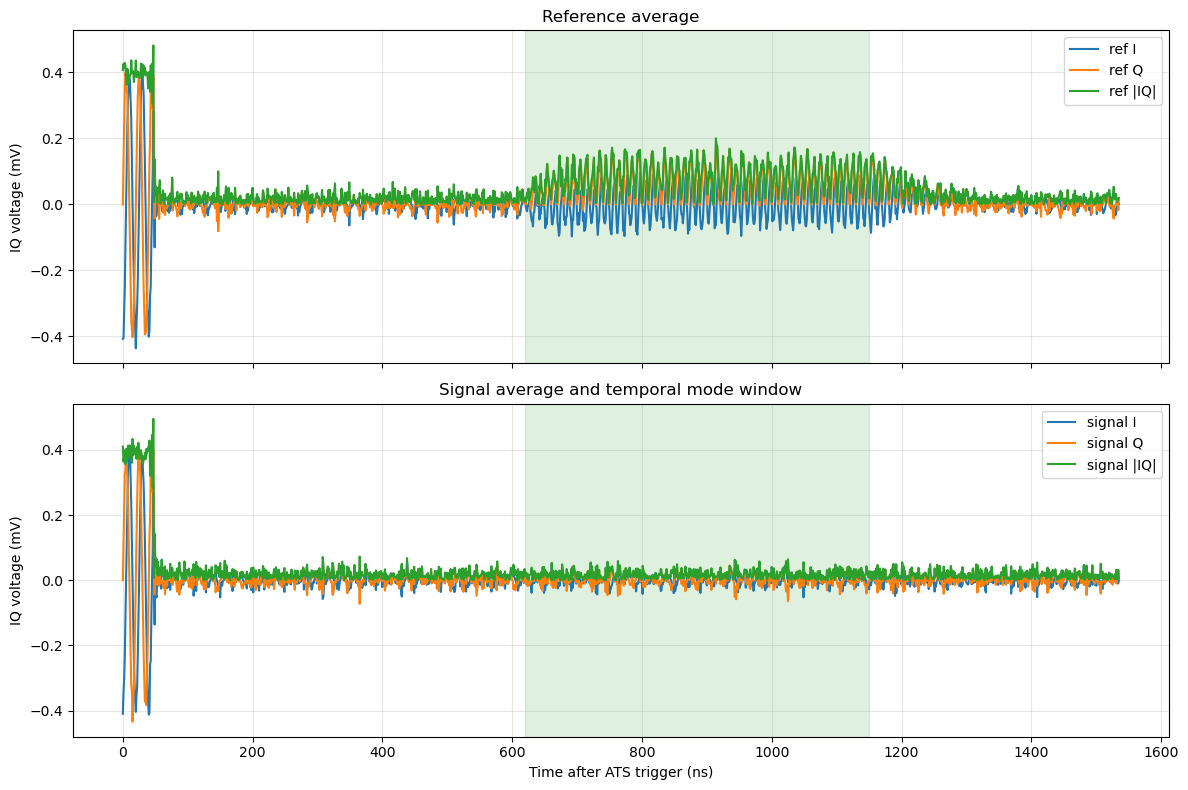

In [145]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(tomo_iq_time_ns, reference_average.real * 1e3, label="ref I")
axes[0].plot(tomo_iq_time_ns, reference_average.imag * 1e3, label="ref Q")
axes[0].plot(tomo_iq_time_ns, np.abs(reference_average) * 1e3, label="ref |IQ|")
axes[0].axvspan(TOMO_MODE_START_NS, TOMO_MODE_STOP_NS, color="tab:green", alpha=0.15)
axes[0].set_title("Reference average")
axes[0].set_ylabel("IQ voltage (mV)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(tomo_iq_time_ns, signal_average.real * 1e3, label="signal I")
axes[1].plot(tomo_iq_time_ns, signal_average.imag * 1e3, label="signal Q")
axes[1].plot(tomo_iq_time_ns, np.abs(signal_average) * 1e3, label="signal |IQ|")
axes[1].axvspan(TOMO_MODE_START_NS, TOMO_MODE_STOP_NS, color="tab:green", alpha=0.15)
axes[1].set_title("Signal average and temporal mode window")
axes[1].set_xlabel("Time after ATS trigger (ns)")
axes[1].set_ylabel("IQ voltage (mV)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## Step 6: project the temporal mode and normalize

Mode samples: 530
IQ offset (mode volts): (-1.9327216699074215e-05+0.001503731987915629j)
IQ scale (mode volts / alpha): 0.0007934468032059232
Reference <|alpha|^2>: 1.0
Signal mean alpha: (0.019901764805828046-1.902145738043264j)
Signal <n> estimate from samples: 3.6194501469413094


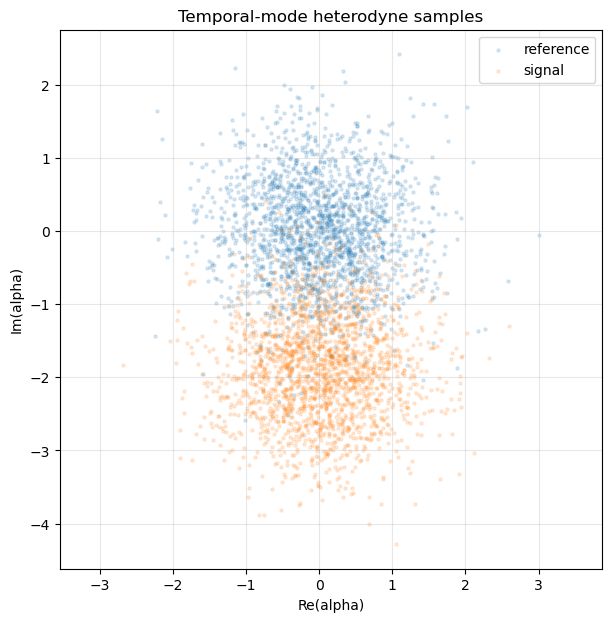

In [146]:
mode_start_sample = experiment.ns2cycles(TOMO_MODE_START_NS, inst="adc")
mode_stop_sample = experiment.ns2cycles(TOMO_MODE_STOP_NS, inst="adc")
mode_samples = mode_stop_sample - mode_start_sample
if mode_samples <= 0:
    raise ValueError("TOMO_MODE_STOP_NS must be greater than TOMO_MODE_START_NS")

mode = temporal_mode_weights(
    mode_samples,
    kind="boxcar",
)
reference_mode_volts = project_temporal_mode(
    reference_iq_traces,
    mode,
    start_sample=mode_start_sample,
)
signal_mode_volts = project_temporal_mode(
    signal_iq_traces,
    mode,
    start_sample=mode_start_sample,
)

alpha_reference, (alpha_signal,), iq_offset, iq_scale = (
    normalize_heterodyne_reference(reference_mode_volts, signal_mode_volts)
)

print("Mode samples:", mode_samples)
print("IQ offset (mode volts):", iq_offset)
print("IQ scale (mode volts / alpha):", iq_scale)
print("Reference <|alpha|^2>:", np.mean(np.abs(alpha_reference) ** 2))
print("Signal mean alpha:", np.mean(alpha_signal))
print("Signal <n> estimate from samples:", np.mean(np.abs(alpha_signal) ** 2) - 1)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(alpha_reference.real, alpha_reference.imag, s=5, alpha=0.15, label="reference")
ax.scatter(alpha_signal.real, alpha_signal.imag, s=5, alpha=0.15, label="signal")
ax.set_xlabel("Re(alpha)")
ax.set_ylabel("Im(alpha)")
ax.set_title("Temporal-mode heterodyne samples")
ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


## Step 7: reconstruct density matrix and Wigner function

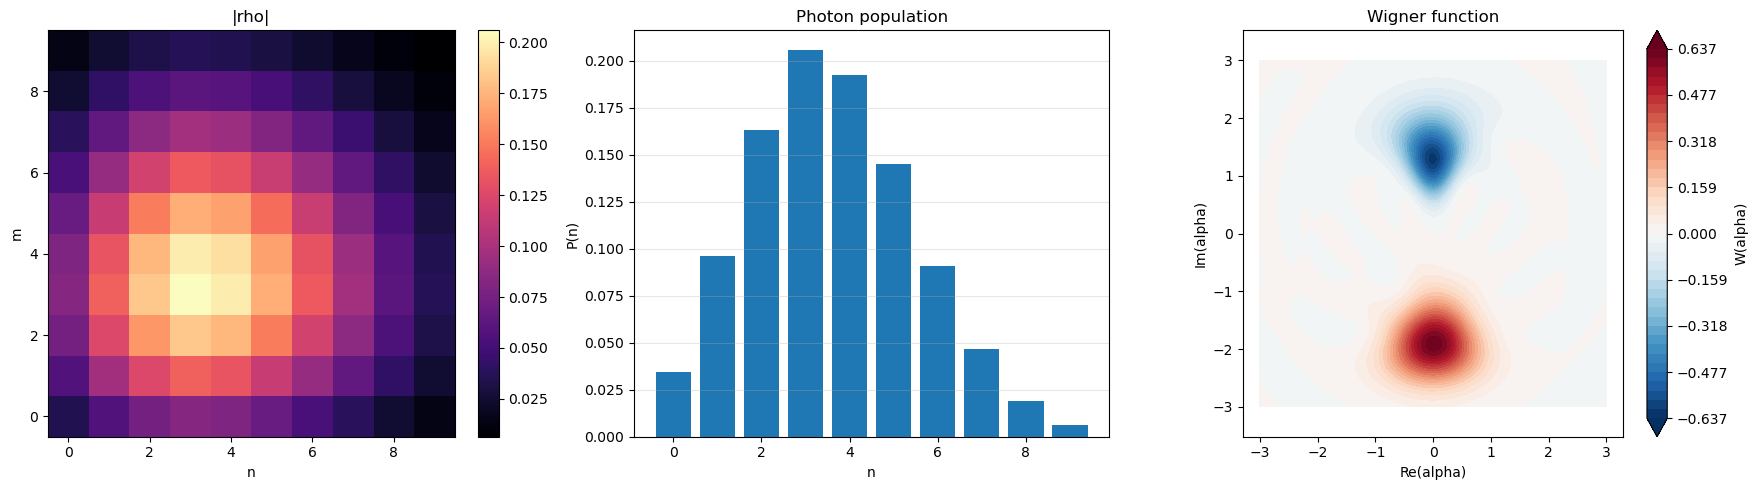

Trace rho: (1.0000000000000002+0j)
Min eigenvalue: -3.952240732585734e-17
Wigner minimum: -0.6217144324312525
Fidelity to coherent state at mean alpha: 0.9909911098253743


In [147]:
FOCK_CUTOFF = 10
ML_ITERATIONS = 200
WIGNER_LIMIT = 3.0
WIGNER_POINTS = 81

rho_ml = heterodyne_ml_density_matrix(
    alpha_signal,
    cutoff=FOCK_CUTOFF,
    iterations=ML_ITERATIONS,
    dilution=0.5,
)

alpha_mean = np.mean(alpha_signal)
rho_coherent = coherent_density_matrix(alpha_mean, cutoff=FOCK_CUTOFF)
fidelity_to_coherent = np.real(np.trace(rho_ml @ rho_coherent))
photon_population = np.real(np.diag(rho_ml))
photon_population = np.maximum(photon_population, 0.0)

axis = np.linspace(-WIGNER_LIMIT, WIGNER_LIMIT, WIGNER_POINTS)
wigner = wigner_function(rho_ml, axis, axis)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
image = axes[0].imshow(np.abs(rho_ml), origin="lower", cmap="magma")
axes[0].set_title("|rho|")
axes[0].set_xlabel("n")
axes[0].set_ylabel("m")
plt.colorbar(image, ax=axes[0], fraction=0.046)

axes[1].bar(np.arange(FOCK_CUTOFF), photon_population)
axes[1].set_title("Photon population")
axes[1].set_xlabel("n")
axes[1].set_ylabel("P(n)")
axes[1].grid(True, axis="y", alpha=0.3)

levels = np.linspace(-2 / np.pi, 2 / np.pi, 41)
contour = axes[2].contourf(
    axis,
    axis,
    wigner,
    levels=levels,
    cmap="RdBu_r",
    extend="both",
)
axes[2].set_title("Wigner function")
axes[2].set_xlabel("Re(alpha)")
axes[2].set_ylabel("Im(alpha)")
axes[2].axis("equal")
plt.colorbar(contour, ax=axes[2], label="W(alpha)")

plt.tight_layout()
plt.show()

print("Trace rho:", np.trace(rho_ml))
print("Min eigenvalue:", np.min(np.linalg.eigvalsh(rho_ml)))
print("Wigner minimum:", np.min(wigner))
print("Fidelity to coherent state at mean alpha:", fidelity_to_coherent)


## Step 8: save tomography test

In [88]:
np.savez_compressed(
    "resonator_tomography_test.npz",
    tomo_iq_time_ns=tomo_iq_time_ns,
    reference_mode_volts=reference_mode_volts,
    signal_mode_volts=signal_mode_volts,
    alpha_reference=alpha_reference,
    alpha_signal=alpha_signal,
    rho_ml=rho_ml,
    wigner_axis=axis,
    wigner=wigner,
    iq_offset=iq_offset,
    iq_scale=iq_scale,
    tomo_mode_start_ns=TOMO_MODE_START_NS,
    tomo_mode_stop_ns=TOMO_MODE_STOP_NS,
)
print("Saved resonator_tomography_test.npz")


Saved resonator_tomography_test.npz


## Close hardware

In [ ]:
if "sgs" in globals():
    sgs.off()
    sgs.configure_lo_output(False)
    sgs.close()
    print("SGS100A RF and rear LO outputs disabled")

if "experiment" in globals():
    experiment.close()
    print("AWG VISA session closed")